# Biểu đồ EDA - Fraud Detection Dataset

**Các phần:**
1. Giao dịch diễn ra vào thời điểm nào
2. Sender persona nào bị fraud nhiều nhất
3. Top IP address bị nhiều fraud
4. So sánh Fraud vs Non-Fraud theo transaction_type / payment_channel / device_used
5. Top merchant category
6. Phân bố số tiền giao dịch
7. Tỉ lệ Fraud vs Non-Fraud
8. Location nào diễn ra nhiều fraud nhất

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
dtype = {
    # category
    "transaction_type": "category",
    "merchant_category": "category",
    "location": "category",
    "device_used": "category",
    "fraud_type": "category",
    "payment_channel": "category",
    "ip_address": "category",
    "sender_persona": "category",
    "user_top_category": "category",
    "ip_geo_region": "category",

    # string
    "transaction_id": "string",
    "device_hash": "string",

    # uint64
    "sender_account": "uint64",
    "receiver_account": "uint64",

    # uint8
    "is_fraud": "uint8",
    "velocity_score": "uint8",
    "bvn_linked": "uint8",
    "new_device_transaction": "uint8",
    "geospatial_velocity_anomaly": "uint8",
    "txn_hour": "uint8",
    "is_weekend": "uint8",
    "is_salary_week": "uint8",
    "is_night_txn": "uint8",
    "device_seen_count": "uint8",
    "is_device_shared": "uint8",
    "is_ip_shared": "uint8",
    "user_txn_count_total": "uint8",
    "user_txn_frequency_24h": "uint8",
    "txn_count_last_1h": "uint8",
    "txn_count_last_24h": "uint8",

    # uint16
    "ip_seen_count": "uint16",

    # float32
    "time_since_last_transaction": "float32",
    "spending_deviation_score": "float32",
    "geo_anomaly_score": "float32",
    "amount_ngn": "float32",
    "user_avg_txn_amt": "float32",
    "user_std_txn_amt": "float32",
    "total_amount_last_1h": "float32",
    "time_since_last": "float32",
    "avg_gap_between_txns": "float32",
    "merchant_fraud_rate": "float32",
    "channel_risk_score": "float32",
    "persona_fraud_risk": "float32",
    "location_fraud_risk": "float32",
}

In [3]:
df = pd.read_csv(
    'data/transactions.csv',
    dtype=dtype,
    parse_dates=["timestamp"],
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 45 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   transaction_id               string        
 1   timestamp                    datetime64[us]
 2   sender_account               uint64        
 3   receiver_account             uint64        
 4   transaction_type             category      
 5   merchant_category            category      
 6   location                     category      
 7   device_used                  category      
 8   is_fraud                     uint8         
 9   fraud_type                   category      
 10  time_since_last_transaction  float32       
 11  spending_deviation_score     float32       
 12  velocity_score               uint8         
 13  geo_anomaly_score            float32       
 14  payment_channel              category      
 15  ip_address                   category      
 16  device_hash

In [ ]:
night = np.array([22,23,0,1,2,3,4,5,6])
df['is_night'] = (df['txn_hour'].isin(night)).astype('uint8')
df.pop('is_night_txn')
df

,transaction_id,timestamp,sender_account,receiver_account,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,...,txn_count_last_24h,total_amount_last_1h,time_since_last,avg_gap_between_txns,merchant_fraud_rate,channel_risk_score,persona_fraud_risk,location_fraud_risk,ip_geo_region,is_night
0,T2162315,2023-01-24 09:54:06.198396,1000018177,8385560081,deposit,Local Market Purchase,Aba,mobile,0,NaN,...,1,6.541351e+05,0.000000,0.000000,0.100000,0.8,0.5,0.100000,South East,0
1,T1764581,2023-02-22 16:16:19.271951,1000018177,5643014197,payment,SPAR Purchase,Onitsha,mobile,0,NaN,...,2,6.874491e+05,42142.218750,21071.109375,0.100000,0.3,0.5,0.100000,South East,0
2,T3305551,2023-05-04 16:01:42.312142,1000018177,7722691989,withdrawal,Other Transaction,Onitsha,web,0,NaN,...,3,7.199858e+05,102225.382812,48122.535156,0.100000,0.8,0.5,0.000000,South East,0
3,T174955,2023-05-07 13:15:03.037215,1000018177,4987435115,payment,Ikeja Electric Bill,Benin City,atm,0,NaN,...,4,7.334309e+05,4153.345215,37130.238281,0.100000,0.3,0.5,0.100000,South South,0
4,T3695059,2023-06-08 11:37:39.155188,1000018177,7939643449,withdrawal,Arik Air Flight,Aba,web,0,NaN,...,5,8.585434e+05,45982.601562,38900.710938,0.100000,0.6,0.5,0.000000,South East,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,T2319152,2023-11-23 16:22:20.971217,9999973159,5340639823,payment,DSTV Payment,Onitsha,mobile,0,NaN,...,8,1.781014e+07,2771.118896,53822.496094,0.036152,0.3,0.7,0.036069,South East,0
4999996,T2833155,2023-12-25 13:12:33.898607,9999973159,9337859305,deposit,Other Transaction,Aba,web,1,Account Takeover,...,9,1.845492e+07,45890.214844,52941.132812,0.035804,0.6,0.7,0.035637,South East,0
4999997,T2602571,2023-04-04 13:10:39.842999,9999981583,2181306123,transfer,Other Transaction,Kano,mobile,0,NaN,...,1,2.637750e+04,0.000000,0.000000,0.035804,0.8,0.5,0.035995,North West,0
4999998,T3602783,2023-06-05 06:58:30.601173,9999981583,2393061148,transfer,Other Transaction,Enugu,web,0,NaN,...,2,4.381493e+04,88907.843750,44453.921875,0.035804,0.6,0.5,0.035581,South East,1


In [4]:
# GLOBAL STYLE CONFIG 

PALETTE_FRAUD    = "#FF4C4C"   # red  - fraudulent
PALETTE_LEGIT    = "#4CAEFF"   # blue - legitimate
PALETTE_NEUTRAL  = "#6C63FF"   # purple - single distribution
PALETTE_MERCHANT = "#00C49A"   # teal  - merchant
PALETTE_BG       = "#F8F9FC"   # near-white canvas
PALETTE_CARD     = "#FFFFFF"
PALETTE_TEXT     = "#1A1D2E"
PALETTE_GRID     = "#E2E6F0"

sns.set_theme(style="white", font="DejaVu Sans")

BASE_RC = {
    "figure.facecolor":    PALETTE_BG,
    "axes.facecolor":      PALETTE_CARD,
    "axes.edgecolor":      PALETTE_GRID,
    "axes.labelcolor":     PALETTE_TEXT,
    "axes.labelsize":      13,
    "axes.labelpad":       8,
    "axes.titlesize":      15,
    "axes.titlepad":       12,
    "axes.titleweight":    "bold",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.color":          PALETTE_GRID,
    "grid.linewidth":      0.8,
    "grid.alpha":          0.7,
    "xtick.color":         PALETTE_TEXT,
    "ytick.color":         PALETTE_TEXT,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "figure.dpi":          150,
    "savefig.dpi":         150,
    "savefig.bbox":        "tight",
    "savefig.facecolor":   PALETTE_BG,
}
plt.rcParams.update(BASE_RC)

FRAUD_LABELS   = {0: "Non-Fraud", 1: "Fraud"}
FRAUD_COLORS   = {0: PALETTE_LEGIT, 1: PALETTE_FRAUD}
LEGEND_HANDLES = [
    mpatches.Patch(color=PALETTE_LEGIT, label="\u2714 Non-Fraud"),
    mpatches.Patch(color=PALETTE_FRAUD, label="\u2718 Fraud"),
]

TOP_N = 10


In [5]:
def annotate_bars(ax, fmt="{:,.0f}", fontsize=9):
    """Write the value on top of each bar (works for both bar() and barh())."""
    for p in ax.patches:
        w, h = p.get_width(), p.get_height()
        if h != 0 and abs(h) >= abs(w):
            # vertical bar
            val = h
            if pd.isna(val) or val == 0:
                continue
            ax.annotate(fmt.format(val),
                        (p.get_x() + p.get_width() / 2, val),
                        ha="center", va="bottom", fontsize=fontsize,
                        color=PALETTE_TEXT, xytext=(0, 3), textcoords="offset points")
        else:
            # horizontal bar
            val = w
            if pd.isna(val) or val == 0:
                continue
            ax.annotate(fmt.format(val),
                        (val, p.get_y() + p.get_height() / 2),
                        ha="left", va="center", fontsize=fontsize,
                        color=PALETTE_TEXT, xytext=(4, 0), textcoords="offset points")


## 1. Giao dịch diễn ra vào thời điểm nào?
Phân bố số lượng giao dịch theo giờ trong ngày (`txn_hour`), và so sánh giữa ngày thường và cuối tuần (`is_weekend`).

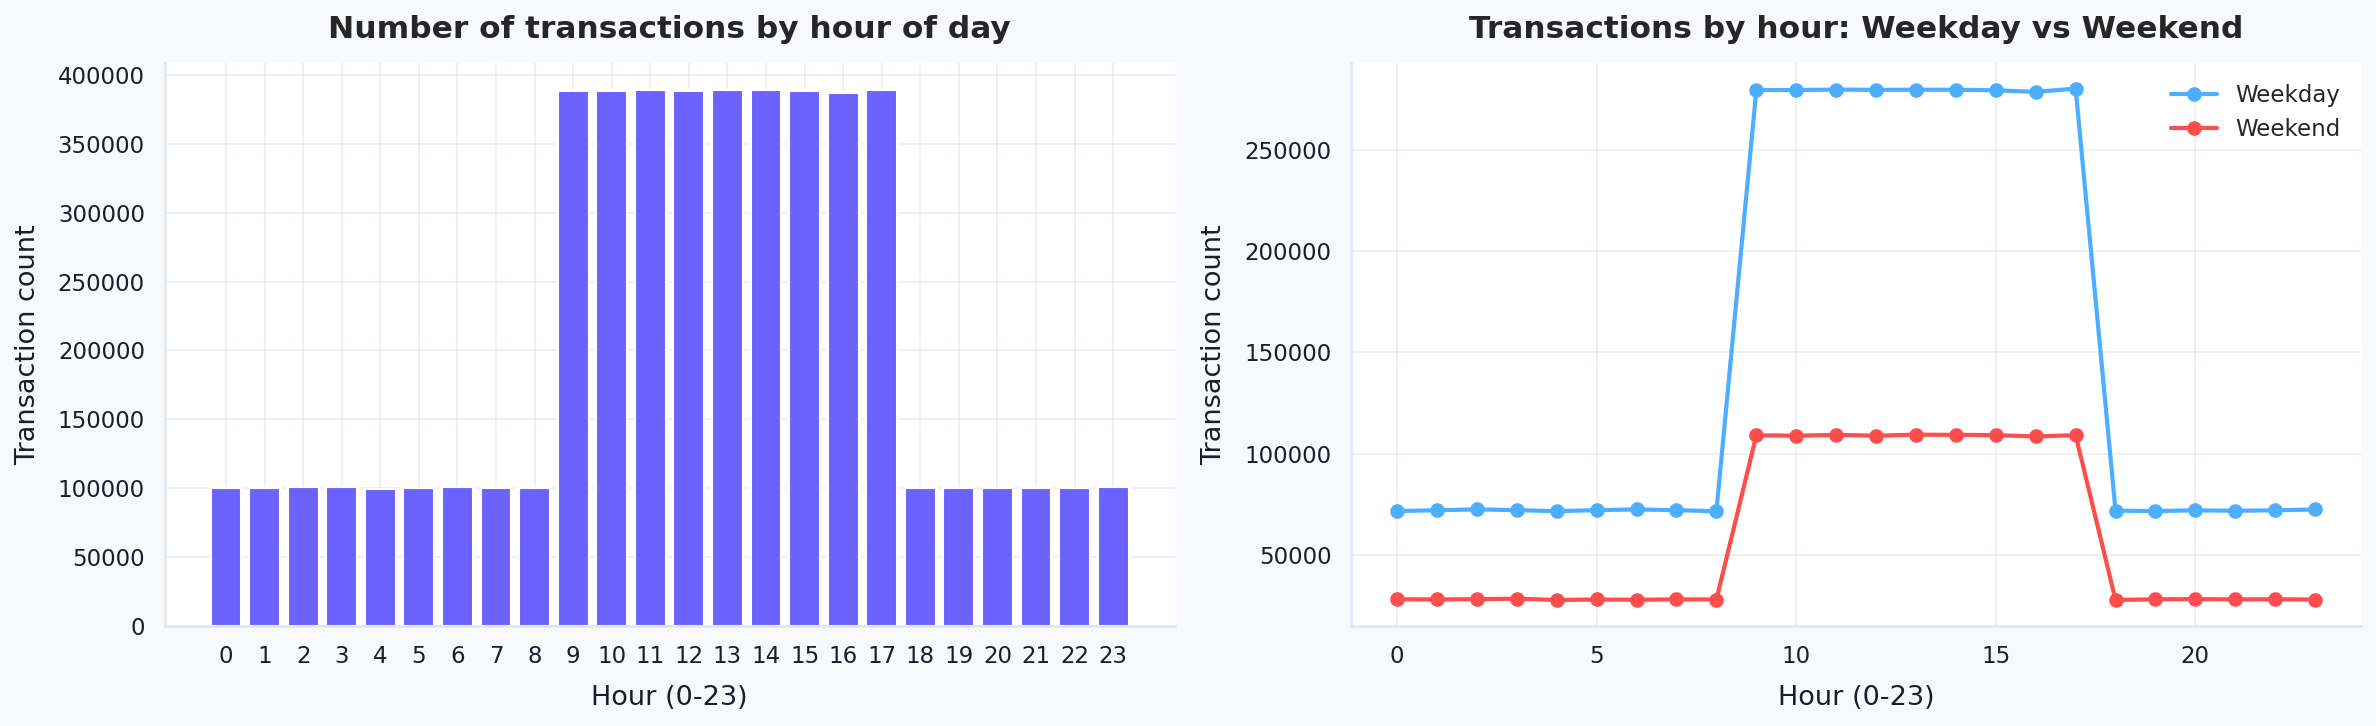

Total transactions: 5,000,000
txn_hour
0      99813
1     100151
2     100692
3     100580
4      99412
5     100163
6     100375
7     100198
8      99662
9     388715
10    388501
11    389134
12    388614
13    389188
14    389080
15    388652
16    387237
17    389491
18     99700
19     99801
20    100249
21     99918
22    100212
23    100462


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Number of transactions per hour of day
hour_counts = df["txn_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=PALETTE_NEUTRAL, edgecolor="white")
# annotate_bars(axes[0], fmt="{:,.0f}")
axes[0].set_title("Number of transactions by hour of day")
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("Transaction count")
axes[0].set_xticks(range(0, 24))

# (b) Hourly pattern: weekday vs weekend
weekend_map = df.groupby(["txn_hour", "is_weekend"]).size().unstack(fill_value=0)
weekend_map.columns = ["Weekday", "Weekend"]
weekend_map.plot(kind="line", marker="o", ax=axes[1],
                  color=[PALETTE_LEGIT, PALETTE_FRAUD], linewidth=2)
axes[1].set_title("Transactions by hour: Weekday vs Weekend")
axes[1].set_xlabel("Hour (0-23)")
axes[1].set_ylabel("Transaction count")
axes[1].legend(title=None, frameon=False)

plt.tight_layout()
plt.show()

print(f"Total transactions: {len(df):,}")
print(hour_counts.rename("count").to_string())


## 2. Sender persona nào bị fraud nhiều nhất?
Trái: số lượng giao dịch fraud theo `sender_persona`. Phải: tỉ lệ fraud (%) theo từng persona - công bằng hơn vì mỗi persona có volume khác nhau.

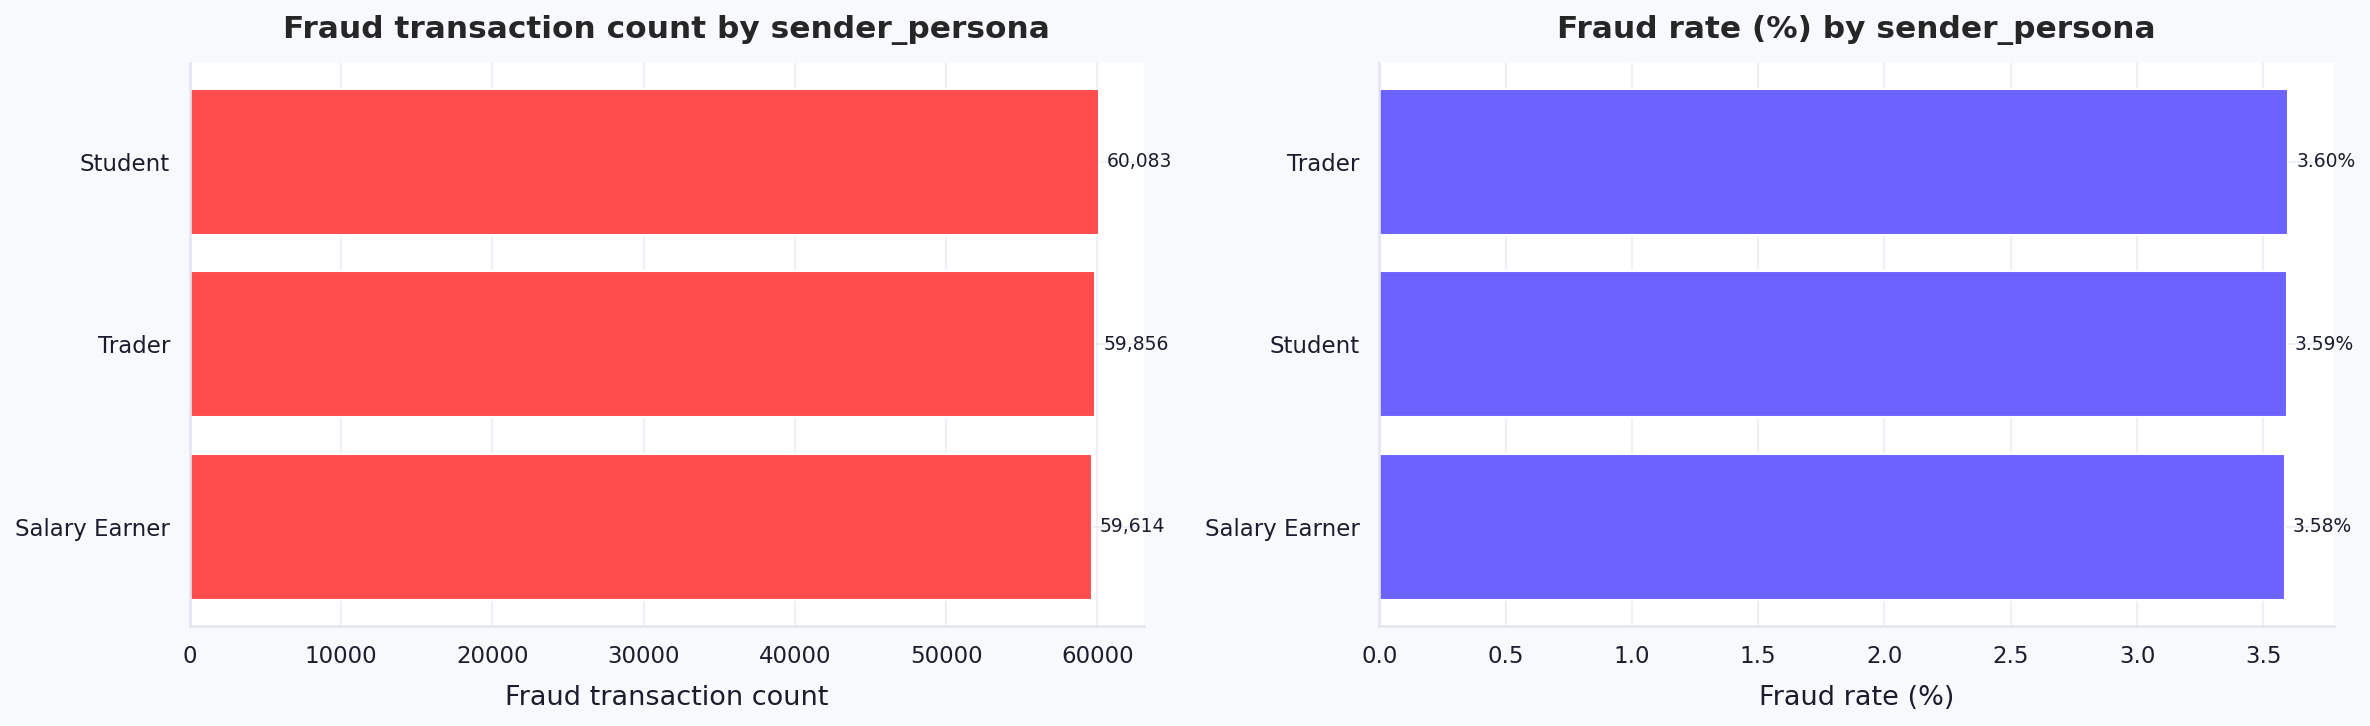

Fraud count by persona:
sender_persona
Student          60083
Trader           59856
Salary Earner    59614

Fraud rate (%) by persona:
sender_persona
Trader           3.598
Student          3.592
Salary Earner    3.584


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

persona_fraud_count = (
    df[df["is_fraud"] == 1]["sender_persona"]
    .value_counts()
    .sort_values(ascending=False)
)
axes[0].barh(persona_fraud_count.index[::-1], persona_fraud_count.values[::-1],
             color=PALETTE_FRAUD, edgecolor="white")
annotate_bars(axes[0], fmt="{:,.0f}")
axes[0].set_title("Fraud transaction count by sender_persona")
axes[0].set_xlabel("Fraud transaction count")

persona_rate = df.groupby("sender_persona")["is_fraud"].mean().sort_values(ascending=False) * 100
axes[1].barh(persona_rate.index[::-1], persona_rate.values[::-1],
             color=PALETTE_NEUTRAL, edgecolor="white")
annotate_bars(axes[1], fmt="{:.2f}%")
axes[1].set_title("Fraud rate (%) by sender_persona")
axes[1].set_xlabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

print("Fraud count by persona:")
print(persona_fraud_count.to_string())
print("\nFraud rate (%) by persona:")
print(persona_rate.round(3).to_string())


## 3. Top những IP address bị nhiều fraud nhất
Top N (mặc định `TOP_N`) giá trị `ip_address` được xếp hạng theo số lượng giao dịch fraud.

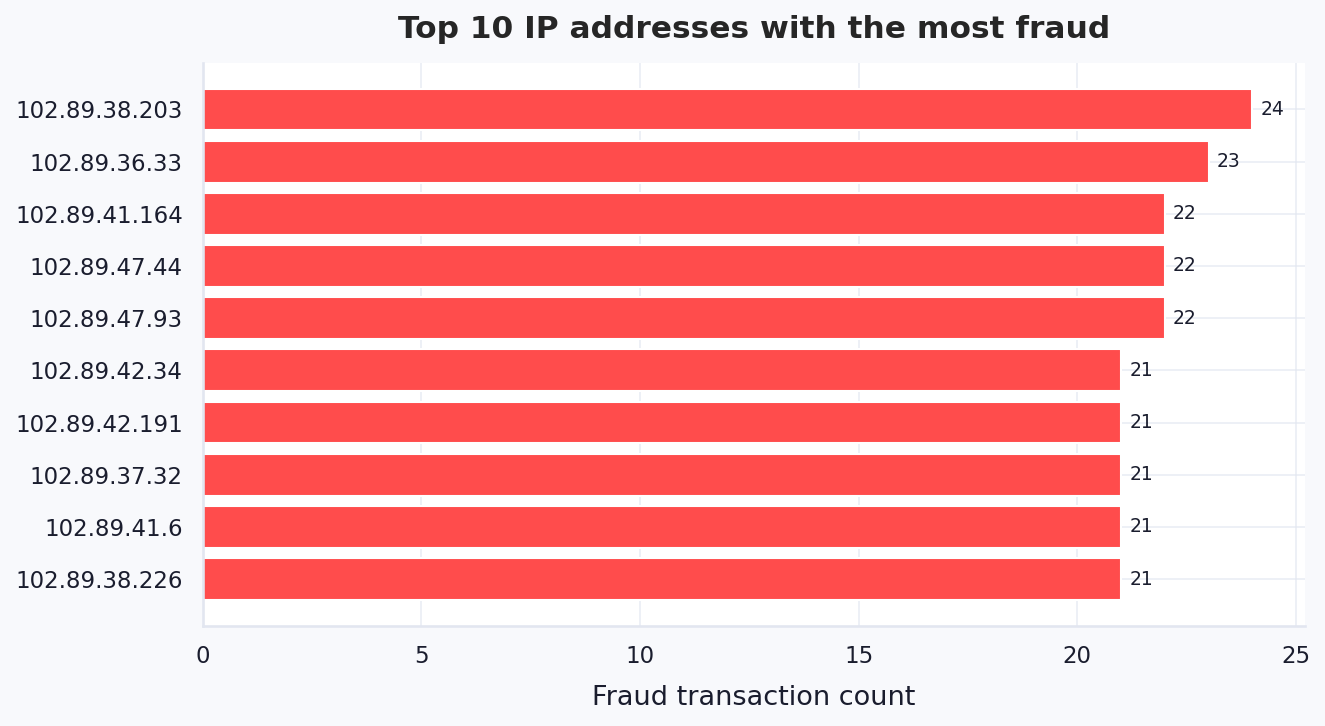

ip_address
102.89.38.203    24
102.89.36.33     23
102.89.47.44     22
102.89.41.164    22
102.89.47.93     22
102.89.38.226    21
102.89.41.6      21
102.89.42.34     21
102.89.37.32     21
102.89.42.191    21


In [8]:
ip_fraud_count = (
    df[df["is_fraud"] == 1]["ip_address"]
    .value_counts()
    .head(TOP_N)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.4)))
ax.barh(ip_fraud_count.index.astype(str), ip_fraud_count.values,
        color=PALETTE_FRAUD, edgecolor="white")
annotate_bars(ax, fmt="{:,.0f}")
ax.set_title(f"Top {TOP_N} IP addresses with the most fraud")
ax.set_xlabel("Fraud transaction count")
plt.tight_layout()
plt.show()

print(ip_fraud_count.sort_values(ascending=False).to_string())


## 4a. So sánh Fraud vs Non-Fraud theo Transaction Type
So sánh giao dịch fraud và non-fraud theo từng `transaction_type` (số lượng tuyệt đối và tỉ lệ fraud %).

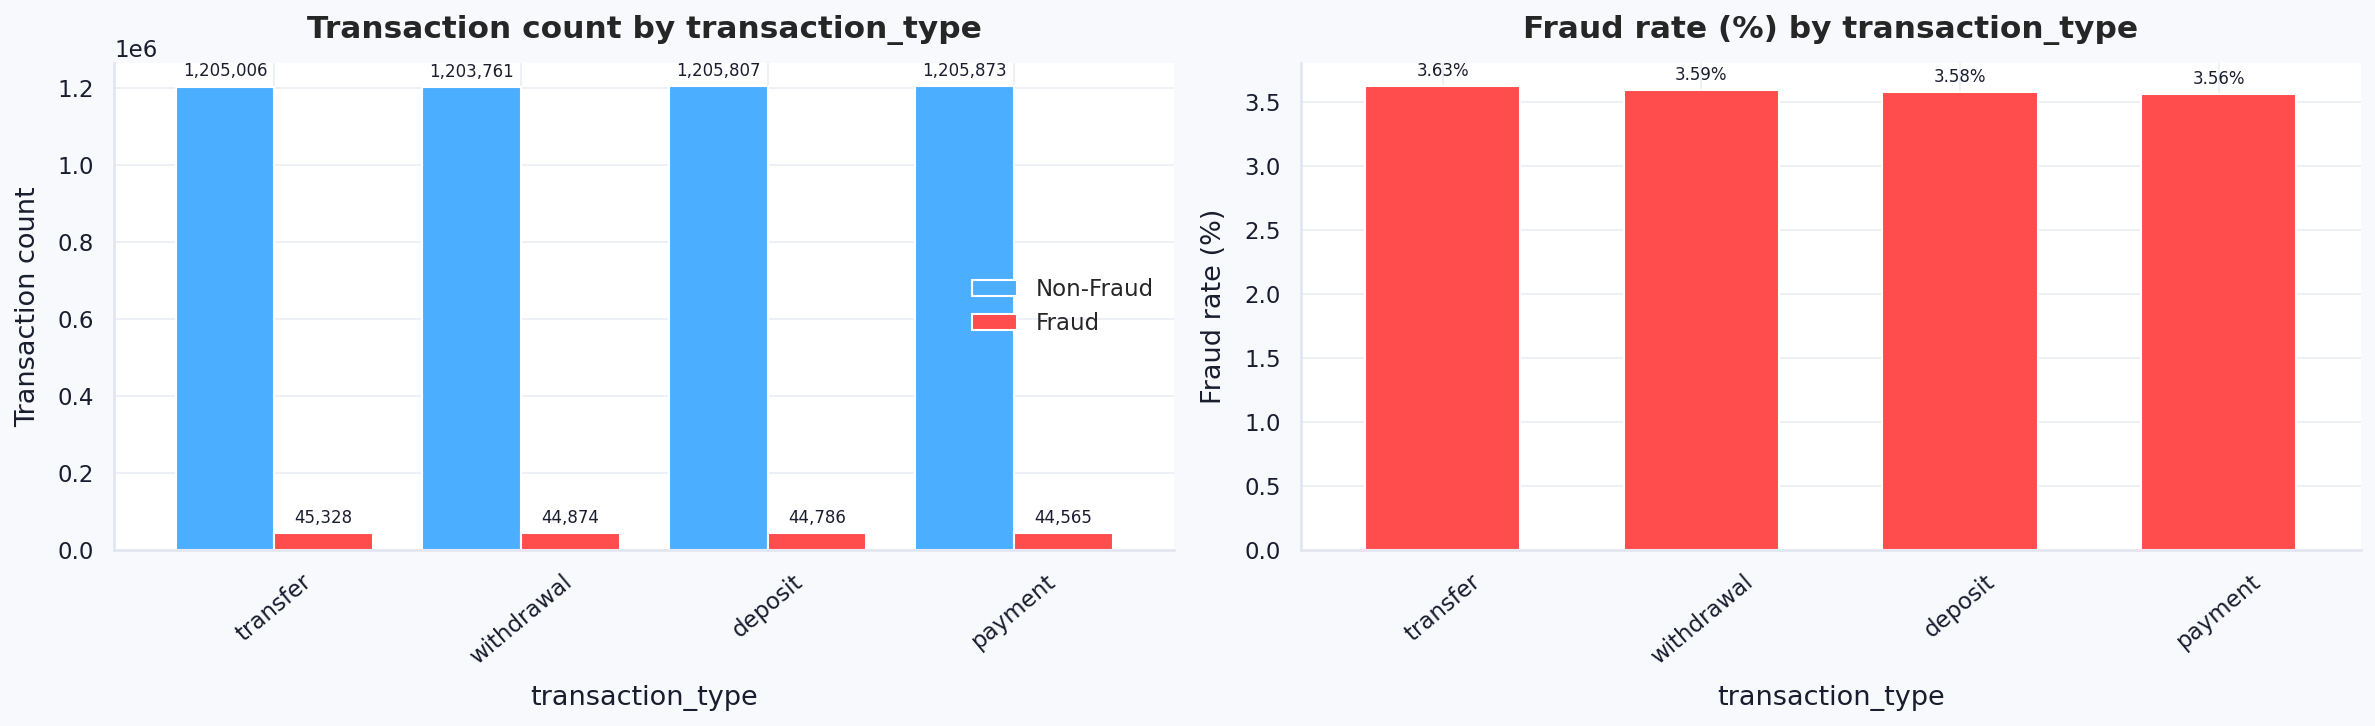

Count table:
                  Non-Fraud  Fraud
transaction_type                  
transfer            1205006  45328
withdrawal          1203761  44874
deposit             1205807  44786
payment             1205873  44565

Fraud rate (%) table:
                  Non-Fraud  Fraud
transaction_type                  
transfer             96.375  3.625
withdrawal           96.406  3.594
deposit              96.419  3.581
payment              96.436  3.564


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute count: Fraud vs Non-Fraud per category
ct_count = pd.crosstab(df["transaction_type"], df["is_fraud"])
ct_count.columns = [FRAUD_LABELS[c] for c in ct_count.columns]
ct_count = ct_count.sort_values("Fraud", ascending=False)
ct_count.plot(kind="bar", ax=axes[0],
              color=[PALETTE_LEGIT, PALETTE_FRAUD], edgecolor="white", width=0.8)
axes[0].set_title(f"Transaction count by transaction_type")
axes[0].set_xlabel("transaction_type")
axes[0].set_ylabel("Transaction count")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(frameon=False)
annotate_bars(axes[0], fmt="{:,.0f}", fontsize=8)

# (b) Fraud rate (%) normalized within each category
ct_pct = pd.crosstab(df["transaction_type"], df["is_fraud"], normalize="index") * 100
ct_pct.columns = [FRAUD_LABELS[c] for c in ct_pct.columns]
ct_pct = ct_pct.sort_values("Fraud", ascending=False)
ct_pct[["Fraud"]].plot(kind="bar", ax=axes[1], color=PALETTE_FRAUD,
                        edgecolor="white", width=0.6, legend=False)
axes[1].set_title(f"Fraud rate (%) by transaction_type")
axes[1].set_xlabel("transaction_type")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=40)
annotate_bars(axes[1], fmt="{:.2f}%", fontsize=8)

plt.tight_layout()
plt.show()

print("Count table:")
print(ct_count.to_string())
print("\nFraud rate (%) table:")
print(ct_pct.round(3).to_string())


## 4b. So sánh Fraud vs Non-Fraud theo Payment Channel
So sánh giao dịch fraud và non-fraud theo từng `payment_channel`.

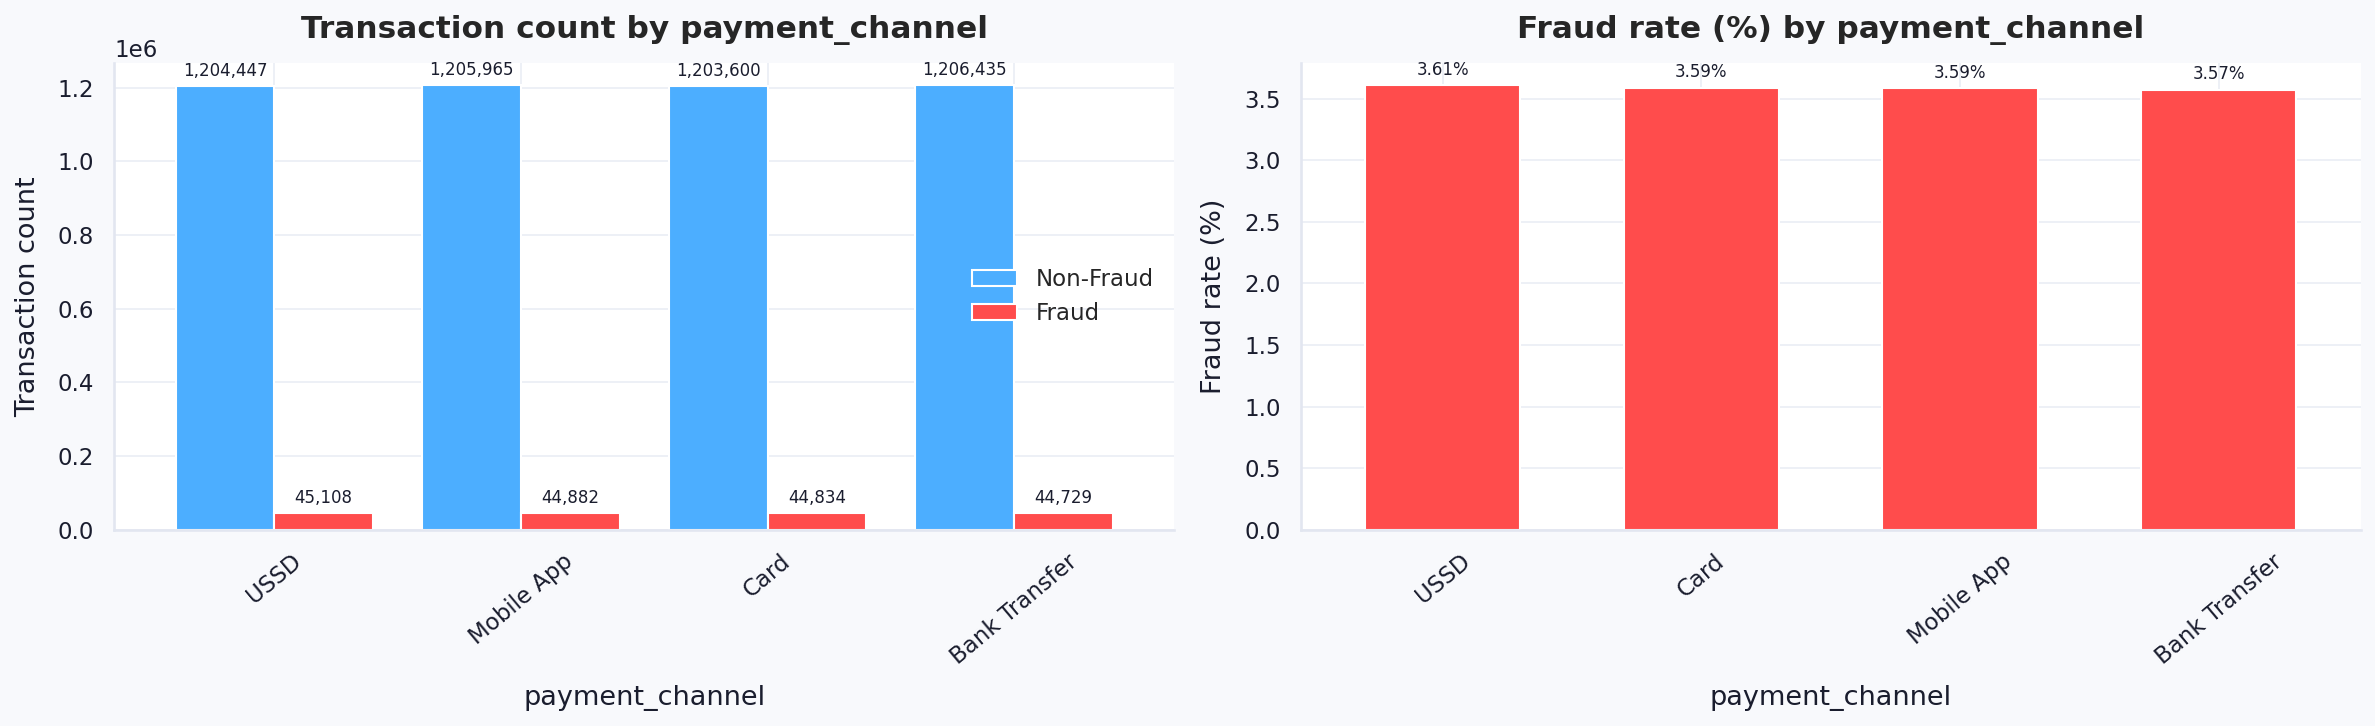

Count table:
                 Non-Fraud  Fraud
payment_channel                  
USSD               1204447  45108
Mobile App         1205965  44882
Card               1203600  44834
Bank Transfer      1206435  44729

Fraud rate (%) table:
                 Non-Fraud  Fraud
payment_channel                  
USSD                96.390  3.610
Card                96.409  3.591
Mobile App          96.412  3.588
Bank Transfer       96.425  3.575


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute count: Fraud vs Non-Fraud per category
ct_count = pd.crosstab(df["payment_channel"], df["is_fraud"])
ct_count.columns = [FRAUD_LABELS[c] for c in ct_count.columns]
ct_count = ct_count.sort_values("Fraud", ascending=False)
ct_count.plot(kind="bar", ax=axes[0],
              color=[PALETTE_LEGIT, PALETTE_FRAUD], edgecolor="white", width=0.8)
axes[0].set_title(f"Transaction count by payment_channel")
axes[0].set_xlabel("payment_channel")
axes[0].set_ylabel("Transaction count")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(frameon=False)
annotate_bars(axes[0], fmt="{:,.0f}", fontsize=8)

# (b) Fraud rate (%) normalized within each category
ct_pct = pd.crosstab(df["payment_channel"], df["is_fraud"], normalize="index") * 100
ct_pct.columns = [FRAUD_LABELS[c] for c in ct_pct.columns]
ct_pct = ct_pct.sort_values("Fraud", ascending=False)
ct_pct[["Fraud"]].plot(kind="bar", ax=axes[1], color=PALETTE_FRAUD,
                        edgecolor="white", width=0.6, legend=False)
axes[1].set_title(f"Fraud rate (%) by payment_channel")
axes[1].set_xlabel("payment_channel")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=40)
annotate_bars(axes[1], fmt="{:.2f}%", fontsize=8)

plt.tight_layout()
plt.show()

print("Count table:")
print(ct_count.to_string())
print("\nFraud rate (%) table:")
print(ct_pct.round(3).to_string())


## 4c. So sánh Fraud vs Non-Fraud theo Device Used
So sánh giao dịch fraud và non-fraud theo từng `device_used`.

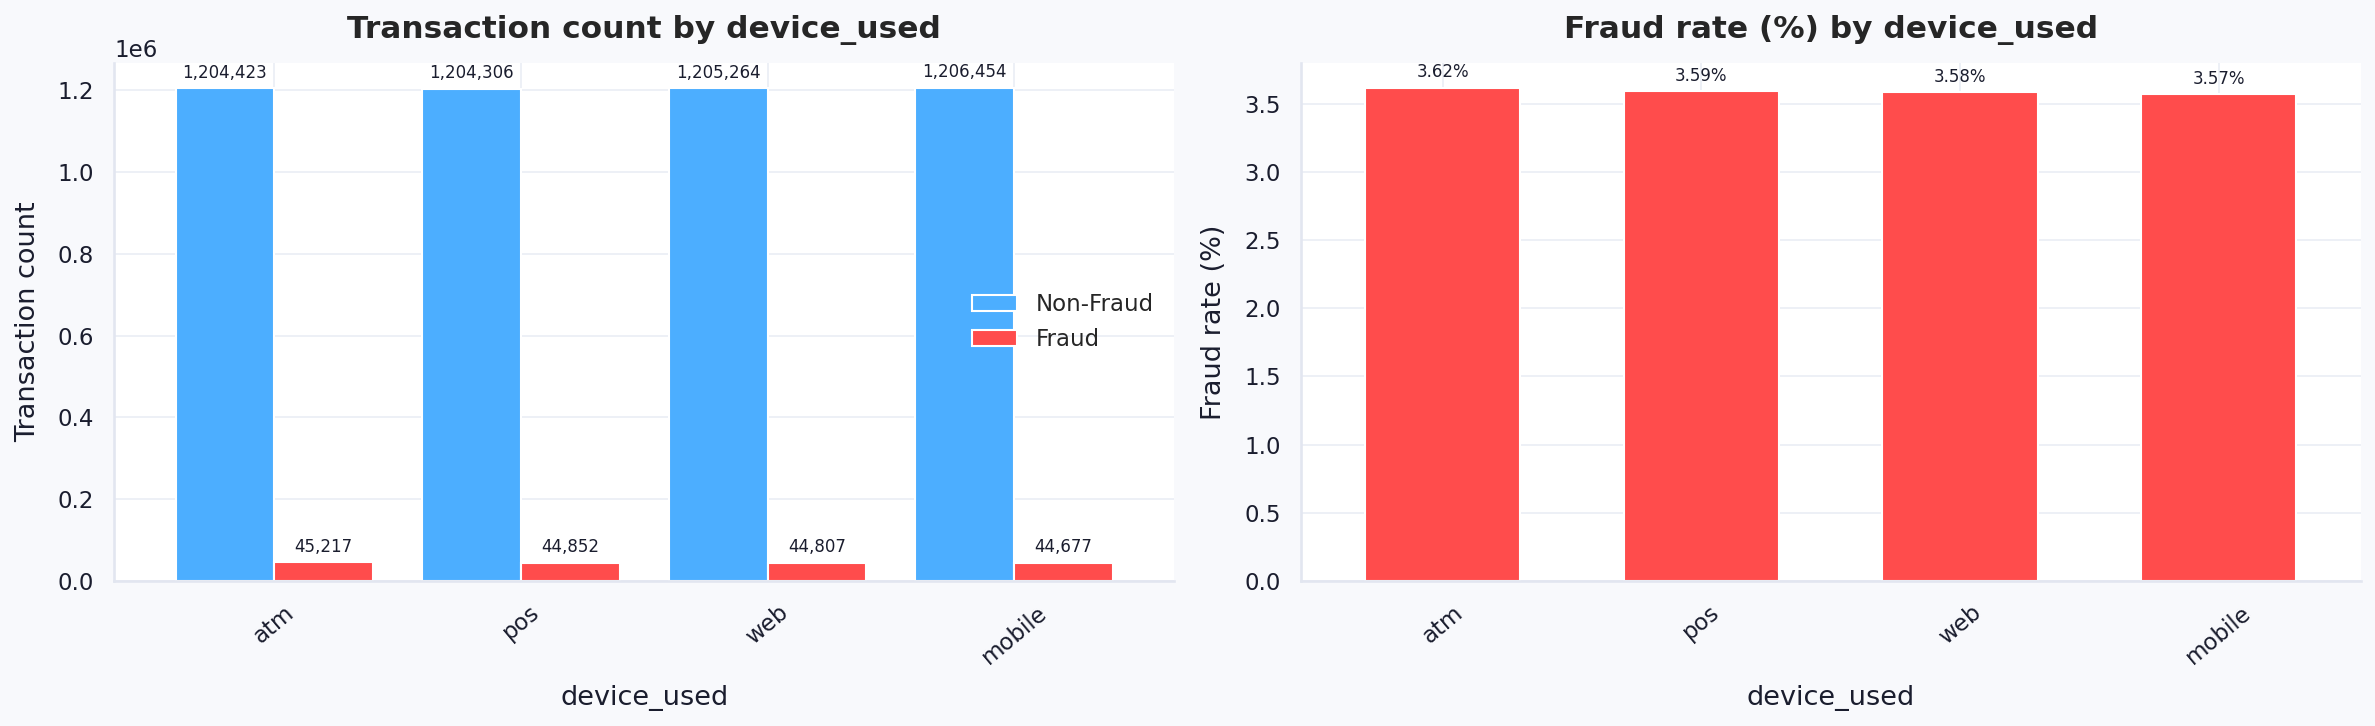

Count table:
             Non-Fraud  Fraud
device_used                  
atm            1204423  45217
pos            1204306  44852
web            1205264  44807
mobile         1206454  44677

Fraud rate (%) table:
             Non-Fraud  Fraud
device_used                  
atm             96.382  3.618
pos             96.409  3.591
web             96.416  3.584
mobile          96.429  3.571


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute count: Fraud vs Non-Fraud per category
ct_count = pd.crosstab(df["device_used"], df["is_fraud"])
ct_count.columns = [FRAUD_LABELS[c] for c in ct_count.columns]
ct_count = ct_count.sort_values("Fraud", ascending=False)
ct_count.plot(kind="bar", ax=axes[0],
              color=[PALETTE_LEGIT, PALETTE_FRAUD], edgecolor="white", width=0.8)
axes[0].set_title(f"Transaction count by device_used")
axes[0].set_xlabel("device_used")
axes[0].set_ylabel("Transaction count")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(frameon=False)
annotate_bars(axes[0], fmt="{:,.0f}", fontsize=8)

# (b) Fraud rate (%) normalized within each category
ct_pct = pd.crosstab(df["device_used"], df["is_fraud"], normalize="index") * 100
ct_pct.columns = [FRAUD_LABELS[c] for c in ct_pct.columns]
ct_pct = ct_pct.sort_values("Fraud", ascending=False)
ct_pct[["Fraud"]].plot(kind="bar", ax=axes[1], color=PALETTE_FRAUD,
                        edgecolor="white", width=0.6, legend=False)
axes[1].set_title(f"Fraud rate (%) by device_used")
axes[1].set_xlabel("device_used")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=40)
annotate_bars(axes[1], fmt="{:.2f}%", fontsize=8)

plt.tight_layout()
plt.show()

print("Count table:")
print(ct_count.to_string())
print("\nFraud rate (%) table:")
print(ct_pct.round(3).to_string())


## 5. Top những merchant category được giao dịch nhiều nhất
Top N giá trị `merchant_category` được xếp hạng theo tổng số giao dịch (bao gồm cả fraud và non-fraud).

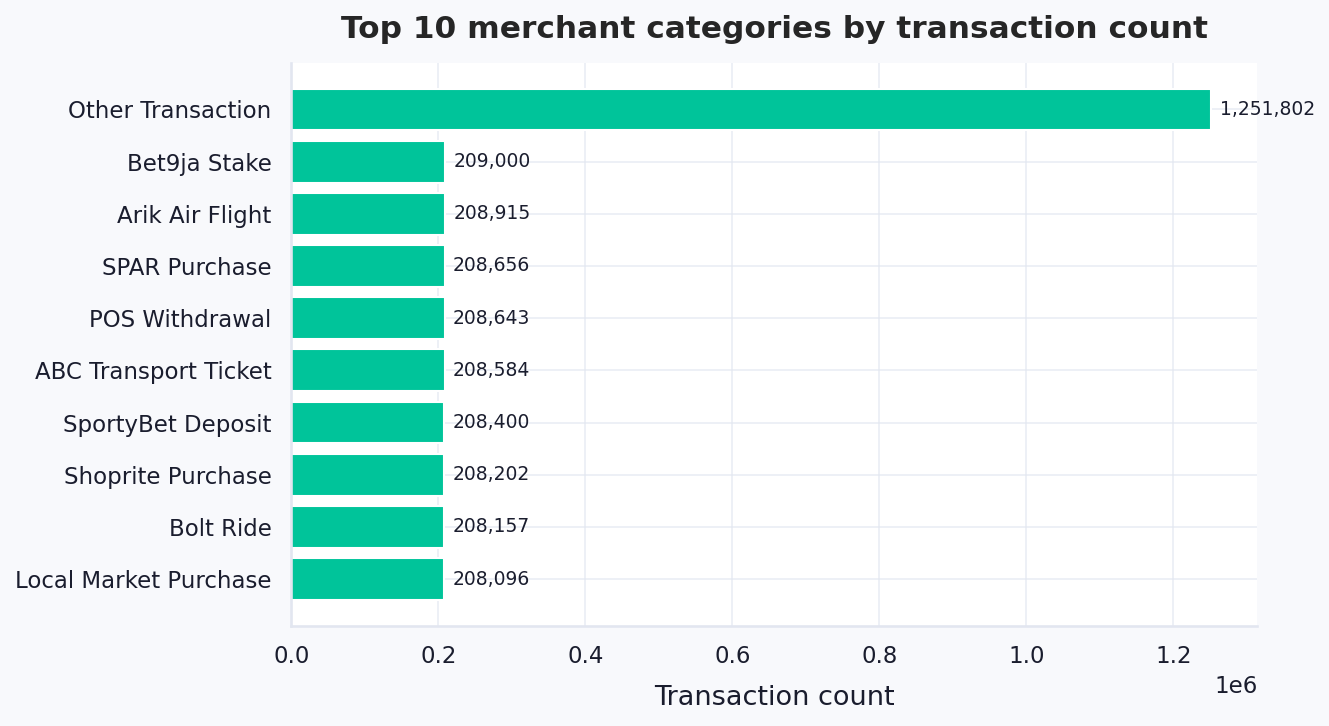

merchant_category
Other Transaction        1251802
Bet9ja Stake              209000
Arik Air Flight           208915
SPAR Purchase             208656
POS Withdrawal            208643
ABC Transport Ticket      208584
SportyBet Deposit         208400
Shoprite Purchase         208202
Bolt Ride                 208157
Local Market Purchase     208096


In [12]:
merchant_counts = df["merchant_category"].value_counts().head(TOP_N).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.4)))
ax.barh(merchant_counts.index.astype(str), merchant_counts.values,
        color=PALETTE_MERCHANT, edgecolor="white")
annotate_bars(ax, fmt="{:,.0f}")
ax.set_title(f"Top {TOP_N} merchant categories by transaction count")
ax.set_xlabel("Transaction count")
plt.tight_layout()
plt.show()

print(merchant_counts.sort_values(ascending=False).to_string())


## 6. Số tiền giao dịch thường thấp hay cao?
Phân bố `amount_ngn` ở cả thang tuyến tính và log, kèm mean/median để xác định độ lệch phải.

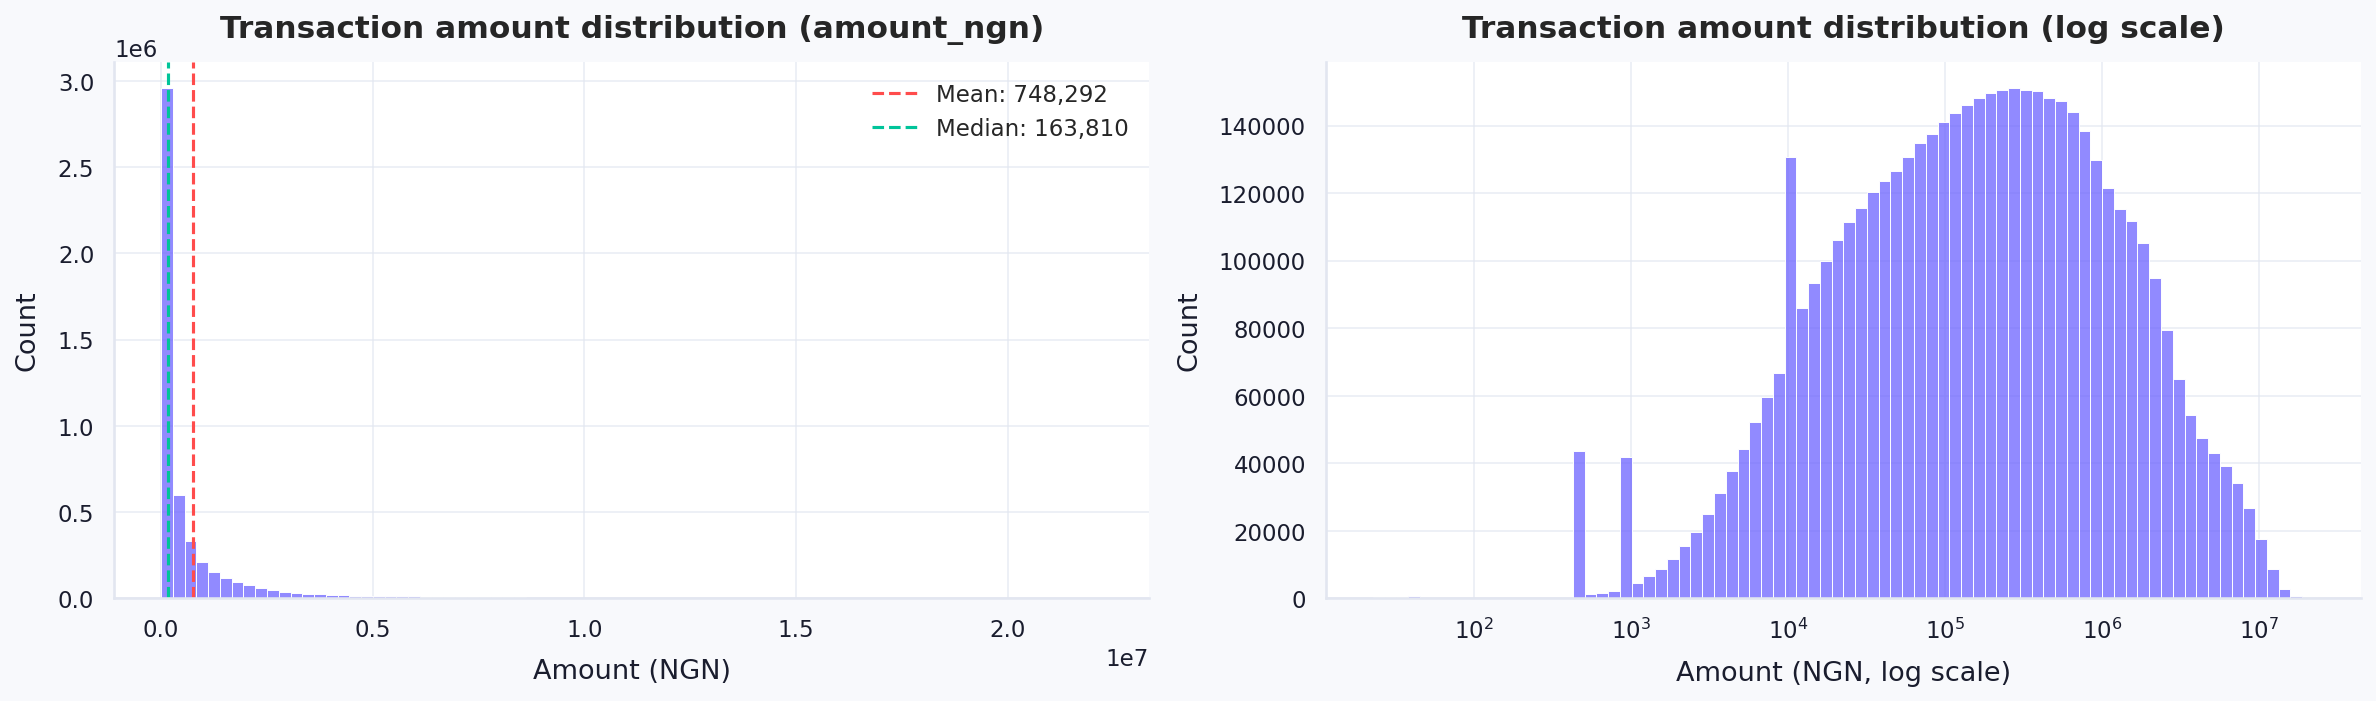

Count:  5,000,000
Mean:   748,292.44 NGN
Median: 163,810.03 NGN
Min:    22.81 NGN
Max:    22,230,670.00 NGN
-> If Mean >> Median: right-skewed distribution (most transactions are small, a few are very large).


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["amount_ngn"], bins=80, color=PALETTE_NEUTRAL, ax=axes[0], kde=False)
mean_val = df["amount_ngn"].mean()
median_val = df["amount_ngn"].median()
axes[0].axvline(mean_val, color=PALETTE_FRAUD, linestyle="--", linewidth=1.5,
                 label=f"Mean: {mean_val:,.0f}")
axes[0].axvline(median_val, color=PALETTE_MERCHANT, linestyle="--", linewidth=1.5,
                 label=f"Median: {median_val:,.0f}")
axes[0].set_title("Transaction amount distribution (amount_ngn)")
axes[0].set_xlabel("Amount (NGN)")
axes[0].legend(frameon=False)

sns.histplot(df["amount_ngn"], bins=80, color=PALETTE_NEUTRAL, ax=axes[1], kde=False, log_scale=True)
axes[1].set_title("Transaction amount distribution (log scale)")
axes[1].set_xlabel("Amount (NGN, log scale)")

plt.tight_layout()
plt.show()

print(f"Count:  {df['amount_ngn'].count():,}")
print(f"Mean:   {mean_val:,.2f} NGN")
print(f"Median: {median_val:,.2f} NGN")
print(f"Min:    {df['amount_ngn'].min():,.2f} NGN")
print(f"Max:    {df['amount_ngn'].max():,.2f} NGN")
print("-> If Mean >> Median: right-skewed distribution (most transactions are small, a few are very large).")


## 7. Tỉ lệ Fraud so với Non-Fraud
Tỉ lệ tổng thể của `is_fraud` (0 = non-fraud, 1 = fraud) trong toàn bộ dataset - thường là tỉ lệ mất cân bằng rất mạnh.

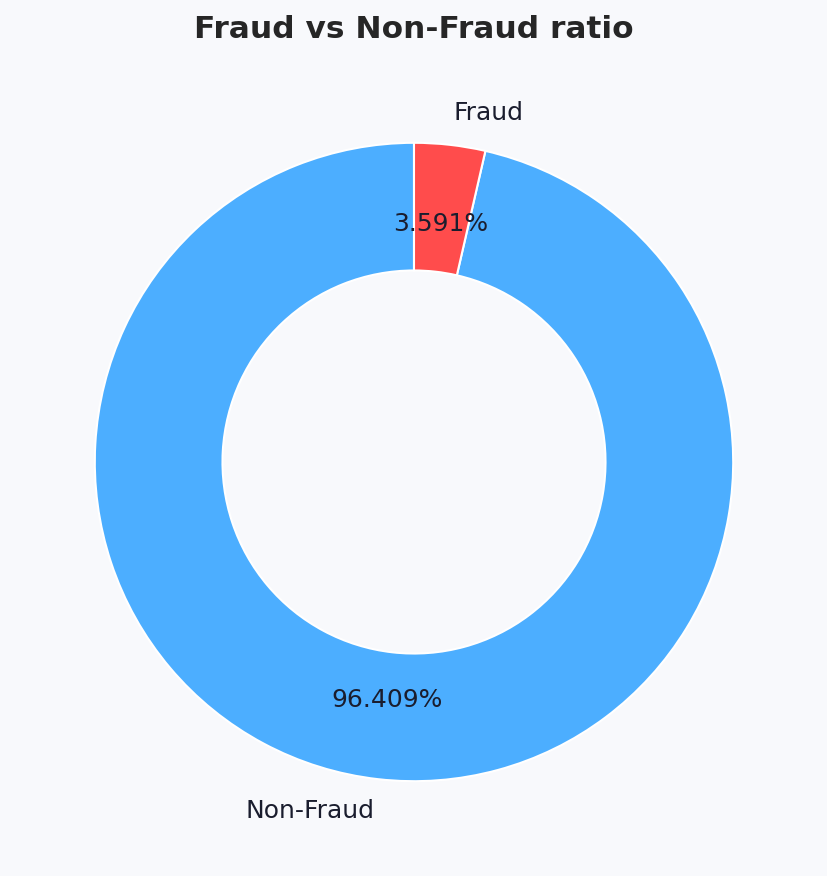

Non-Fraud: 4,820,447 transactions (96.4089%)
Fraud: 179,553 transactions (3.5911%)


In [14]:
counts = df["is_fraud"].value_counts().sort_index()
labels = [FRAUD_LABELS[i] for i in counts.index]
colors = [FRAUD_COLORS[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels, colors=colors, autopct="%1.3f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    textprops=dict(color=PALETTE_TEXT, fontsize=12),
)
ax.set_title("Fraud vs Non-Fraud ratio")
plt.tight_layout()
plt.show()

total = counts.sum()
for i, c in counts.items():
    print(f"{FRAUD_LABELS[i]}: {c:,} transactions ({c/total*100:.4f}%)")


## 8. Location nào diễn ra nhiều fraud nhất?
Trái: top N giá trị `location` xếp hạng theo số lượng fraud tuyệt đối. Phải: top N location xếp hạng theo tỉ lệ fraud (%).

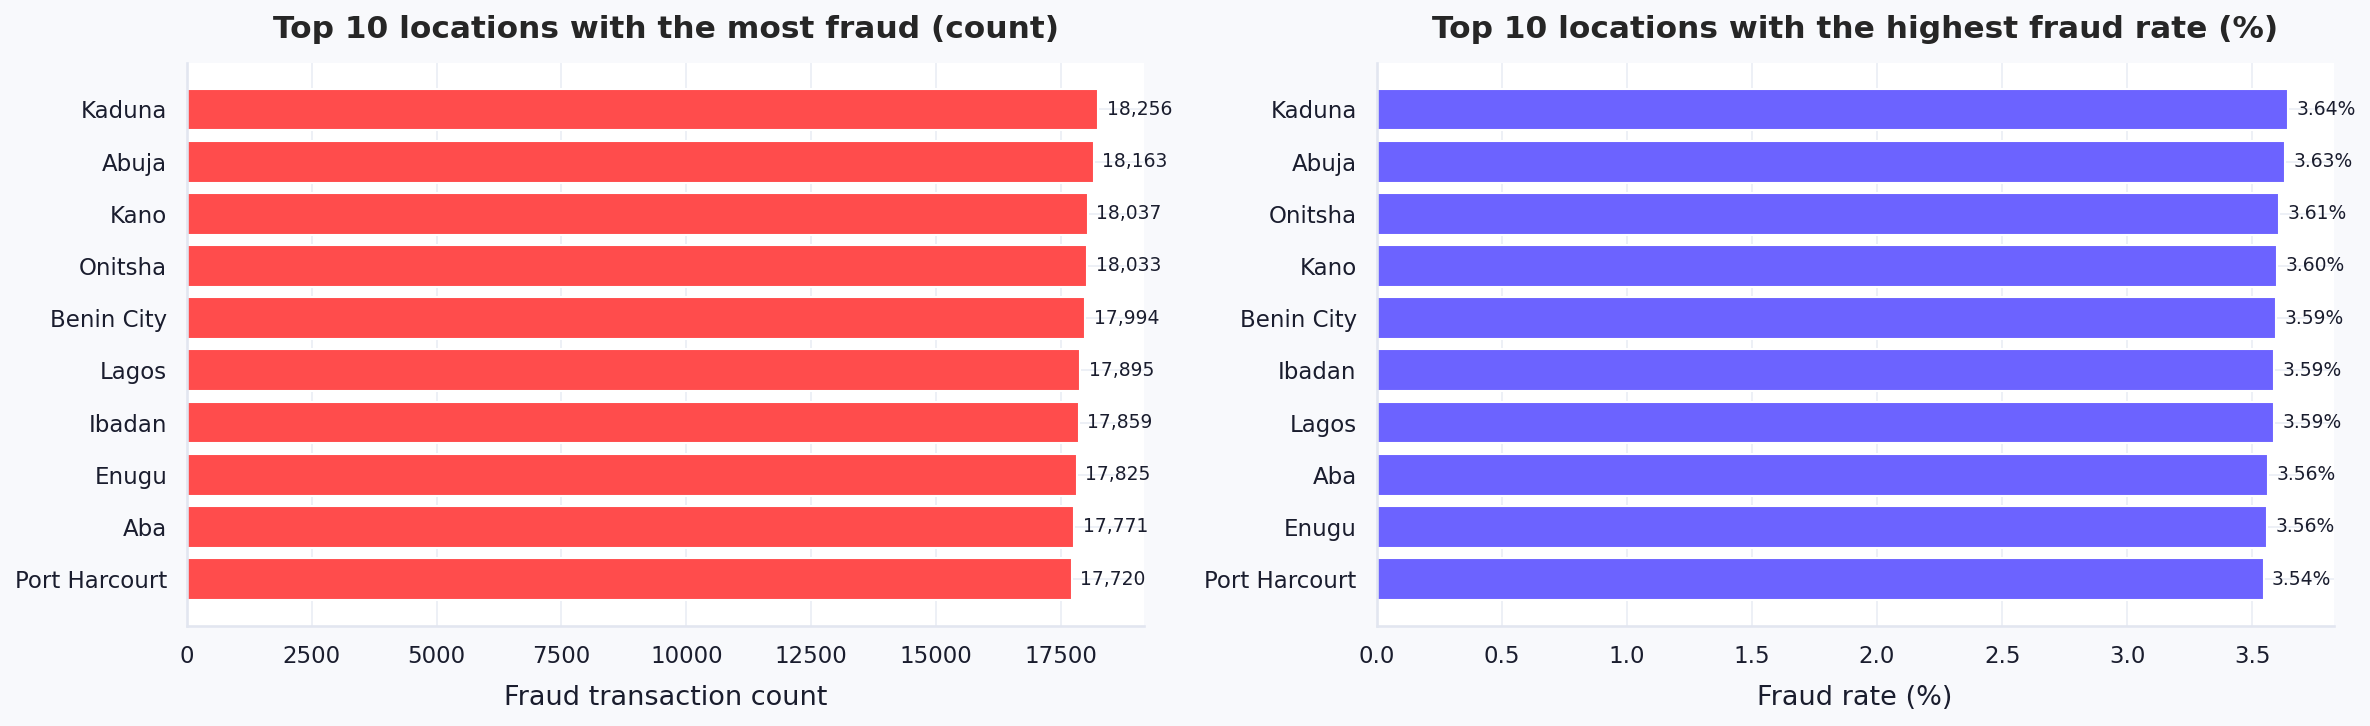

Fraud count by location:
location
Kaduna           18256
Abuja            18163
Kano             18037
Onitsha          18033
Benin City       17994
Lagos            17895
Ibadan           17859
Enugu            17825
Aba              17771
Port Harcourt    17720

Fraud rate (%) by location:
location
Kaduna           3.642
Abuja            3.630
Onitsha          3.607
Kano             3.600
Benin City       3.594
Ibadan           3.587
Lagos            3.585
Aba              3.564
Enugu            3.558
Port Harcourt    3.544


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_fraud_count = (
    df[df["is_fraud"] == 1]["location"]
    .value_counts()
    .head(TOP_N)
    .sort_values(ascending=True)
)
axes[0].barh(loc_fraud_count.index.astype(str), loc_fraud_count.values,
             color=PALETTE_FRAUD, edgecolor="white")
annotate_bars(axes[0], fmt="{:,.0f}")
axes[0].set_title(f"Top {TOP_N} locations with the most fraud (count)")
axes[0].set_xlabel("Fraud transaction count")

loc_fraud_rate = (
    df.groupby("location")["is_fraud"].mean().sort_values(ascending=False).head(TOP_N) * 100
).sort_values(ascending=True)
axes[1].barh(loc_fraud_rate.index.astype(str), loc_fraud_rate.values,
             color=PALETTE_NEUTRAL, edgecolor="white")
annotate_bars(axes[1], fmt="{:.2f}%")
axes[1].set_title(f"Top {TOP_N} locations with the highest fraud rate (%)")
axes[1].set_xlabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

print("Fraud count by location:")
print(loc_fraud_count.sort_values(ascending=False).to_string())
print("\nFraud rate (%) by location:")
print(loc_fraud_rate.sort_values(ascending=False).round(3).to_string())


/tmp/ipykernel_88323/1715337093.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


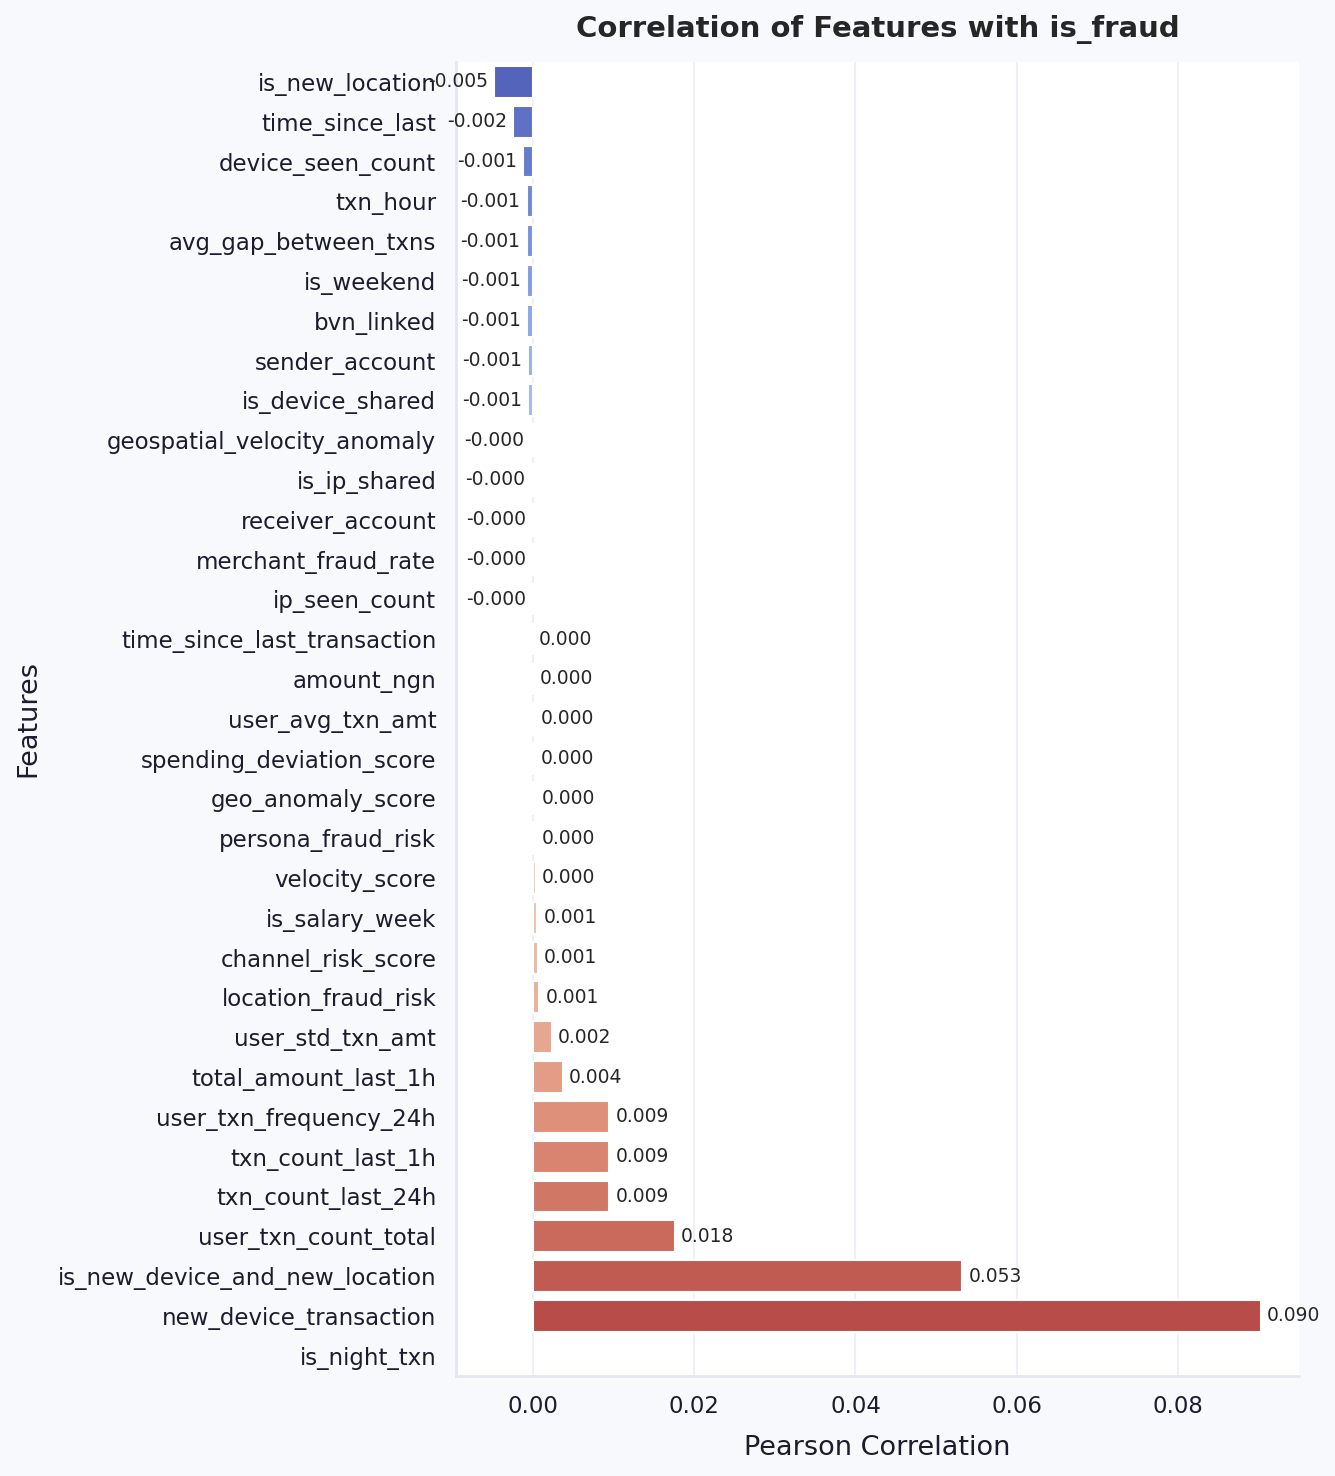

In [20]:
corr_target = (
    df.select_dtypes(include=["number"])
      .corr()["is_fraud"]
      .drop("is_fraud")
      .sort_values()
)

plt.figure(figsize=(9, 10))

ax = sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    palette="coolwarm"
)

# Hiện giá trị correlation trên mỗi thanh
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.title("Correlation of Features with is_fraud", fontsize=14)
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

/home/dangle/code/Financial-Transactions-Fraud-Detection/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dangle/code/Financial-Transactions-Fraud-Detection/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/dangle/code/Financial-Transactions-Fraud-Detection/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dangle/code/Financial-Transactions-Fraud-Detection/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/dangle/code/Financial-Transactions-Fraud-Detection/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in 

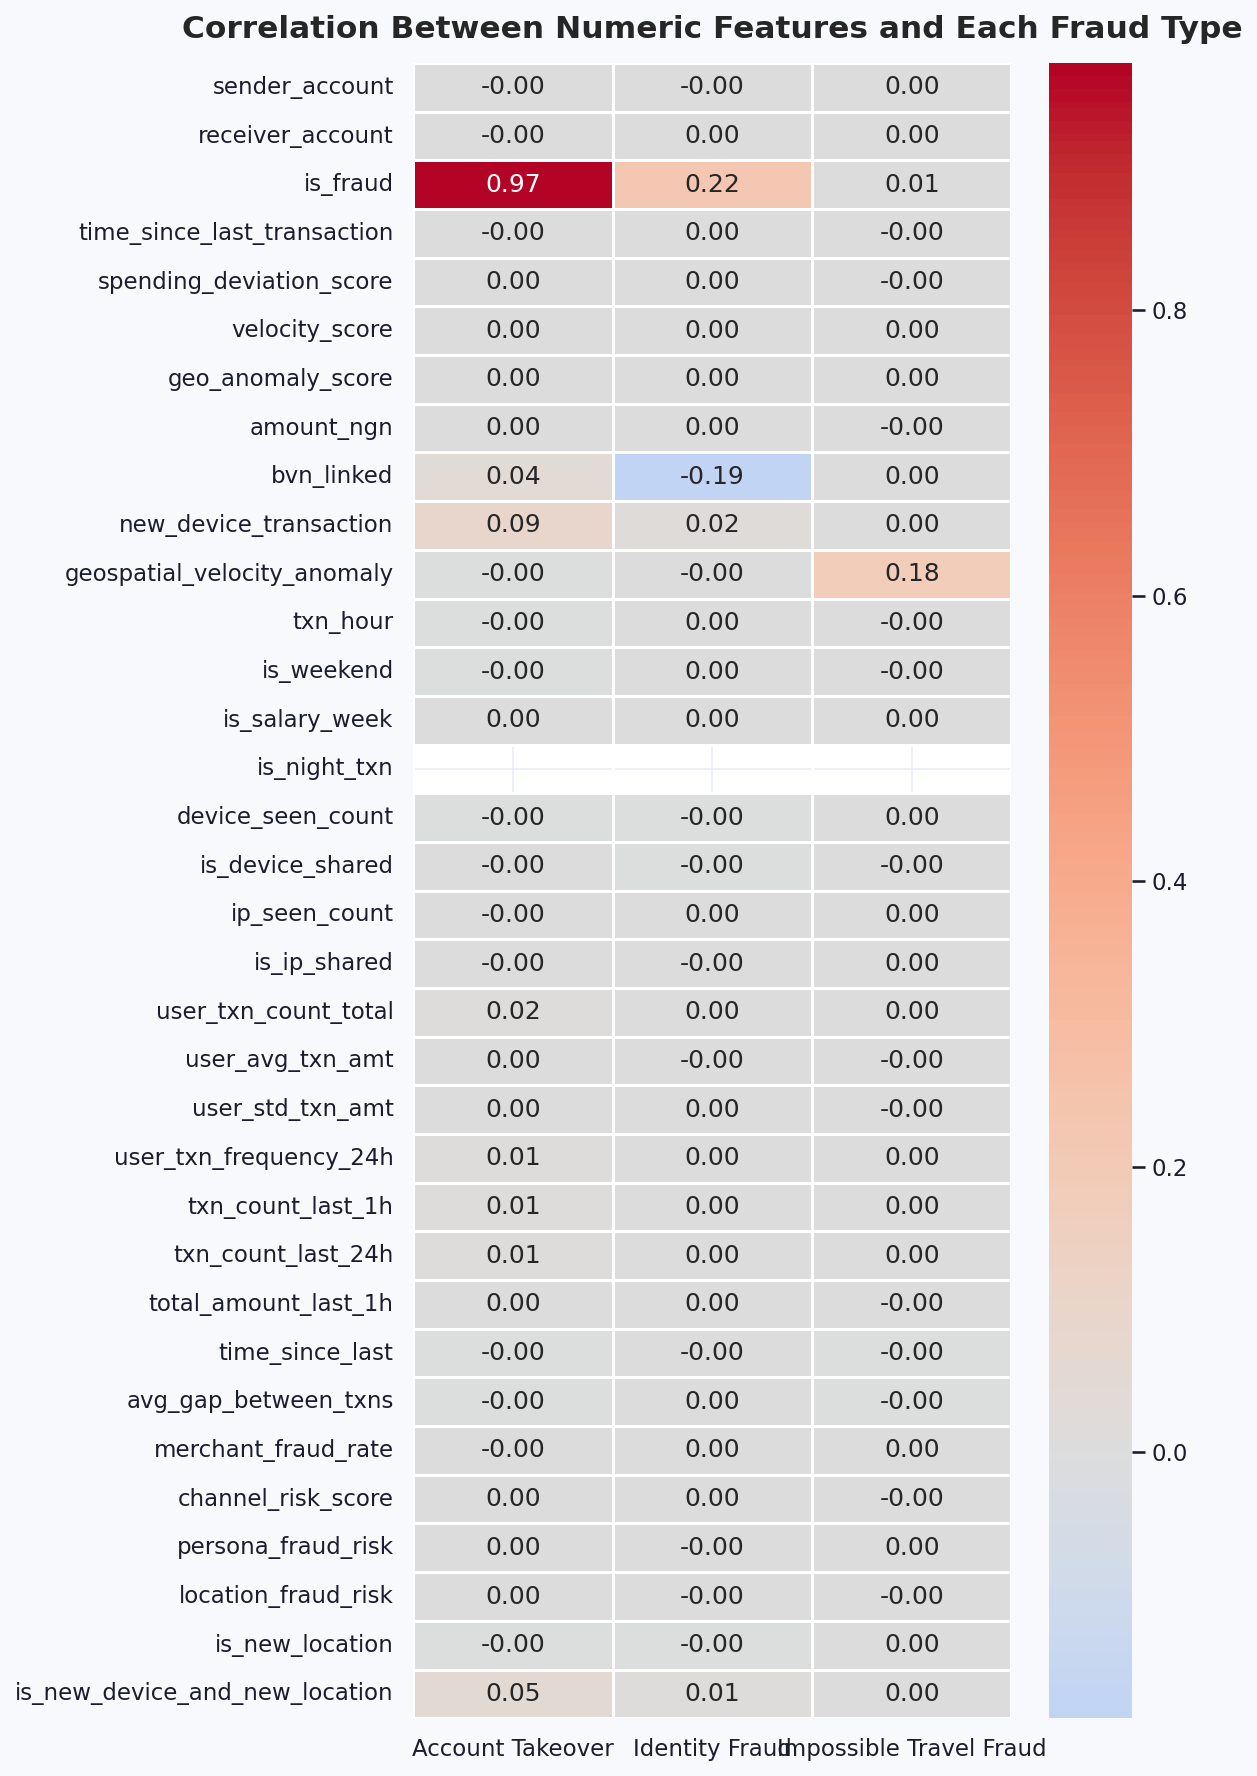

In [19]:
numeric_cols = df.select_dtypes(include="number").columns

corr_df = pd.DataFrame(index=numeric_cols)

for fraud in df["fraud_type"].dropna().unique():
    target = (df["fraud_type"] == fraud).astype(int)
    corr_df[fraud] = df[numeric_cols].corrwith(target)

plt.figure(figsize=(8, 12))

sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Between Numeric Features and Each Fraud Type")
plt.tight_layout()
plt.show()

In [18]:
df = df.sort_values("timestamp")

df["is_new_location"] = (
    ~df.duplicated(["sender_account", "location"])
).astype("uint8")

df["is_new_device_and_new_location"] = (
    (df["new_device_transaction"] == 1) &
    (df["is_new_location"] == 1)
).astype("uint8")

In [16]:
import numpy as np

def f(x,y):
    return np.array([4*x -y, 2 * y -x])

def main():
    x0 = np.array([0,1])
    epochs = 1
    lr = 0.1
    for _ in range(epochs):
        dx = f(x0[0], x0[1])
        x0 = x0 - lr*dx
    print(x0)
    
    
main()

[0.1 0.8]
